In [80]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers (1).csv


In [81]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


The dataset contains 200 customer records with no missing values, ensuring data quality and making it suitable for clustering analysis.

In [83]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


The dataset shows that customers have a wide range of ages, incomes, and spending scores, indicating diverse customer characteristics. The average age is approximately 38 years, while the spending score has a mean of around 50, suggesting a balanced distribution of customer spending behavior.

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

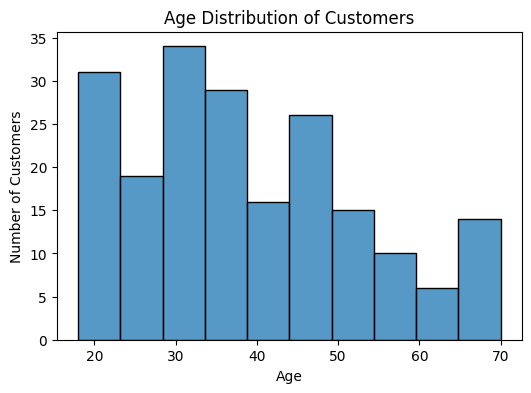

In [85]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Most customers fall between the ages of 25 and 45, indicating a concentration of young to middle-aged consumers within the dataset.

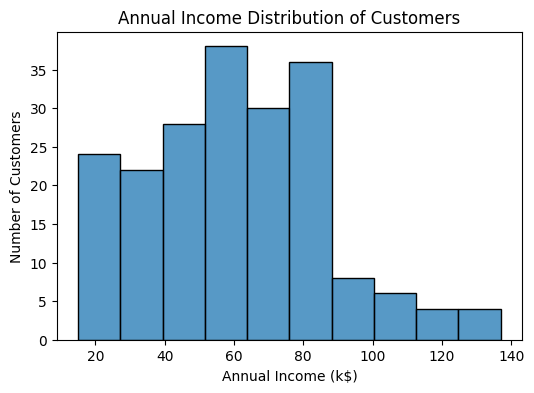

In [86]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=10)

plt.title("Annual Income Distribution of Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

Customer income is widely distributed, with most customers earning between 40k and 80k annually, indicating a concentration within the middle-income range.

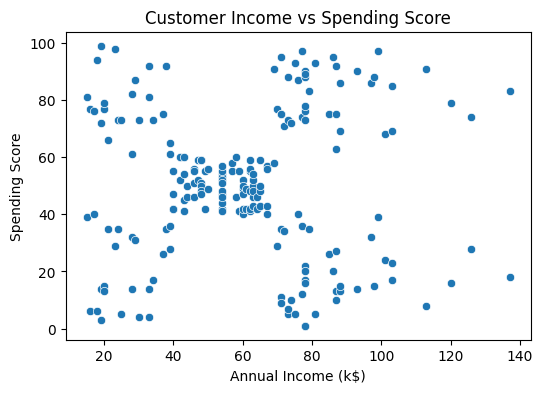

In [87]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

plt.title("Customer Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

The scatter plot reveals distinct groupings of customers based on annual income and spending score, indicating the presence of natural clusters. These patterns suggest that customers exhibit different purchasing behaviors, making clustering techniques such as K-Means appropriate for segmenting customers into meaningful groups for targeted marketing strategie

In [88]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


Three features—Age, Annual Income, and Spending Score—were selected to capture both demographic and behavioral characteristics of customers. These variables provide meaningful insights into customer profiles and purchasing behavior, enabling the clustering algorithm to identify distinct customer segments based on similarities in these attributes.

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

Feature scaling was applied using StandardScaler to standardize the variables, ensuring that all features contribute equally to the clustering process. This prevents variables with larger scales, such as income, from disproportionately influencing the model.

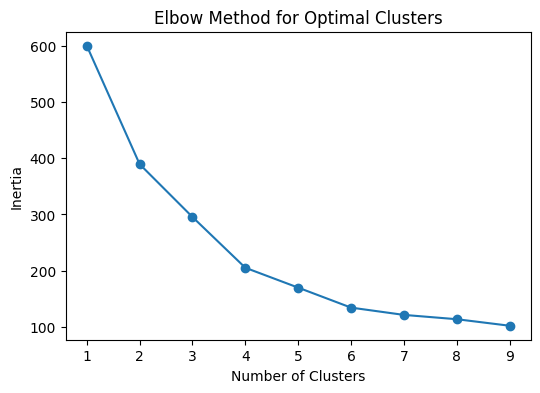

In [90]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

The Elbow Method was used to determine the optimal number of clusters. The plot shows a noticeable bend at k = 5, indicating that this is the optimal number of clusters. Beyond this point, the reduction in inertia becomes less significant, suggesting diminishing returns for additional clusters.

In [91]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


K-Means clustering was applied using k = 5, as determined by the Elbow Method. The algorithm partitions customers into distinct clusters by minimizing the distance between data points and their respective cluster centers, enabling the identification of meaningful customer segments based on age, income, and spending behavior.

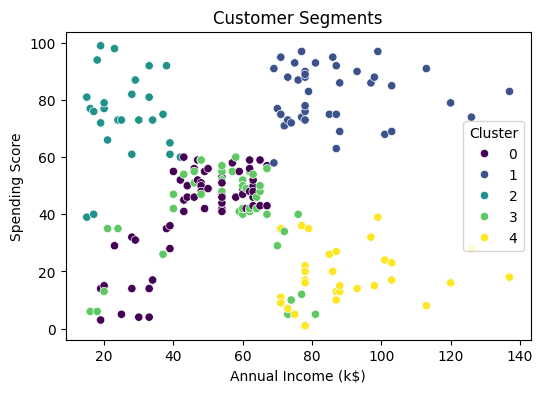

In [92]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

The clustering results reveal distinct customer segments based on income and spending behavior.

One group represents high-income, high-spending customers, who are likely premium or target customers for marketing campaigns.
Another group consists of high-income but low-spending customers, indicating potential for increased engagement and targeted promotions.
A third group includes low-income but high-spending customers, suggesting impulsive or highly engaged buyers.
Additional clusters represent moderate-income and moderate-spending customers, forming the general customer base.

These segments provide valuable insights for businesses to tailor marketing strategies, improve customer targeting, and maximize revenue.

In [93]:
centers = kmeans.cluster_centers_

centers

array([[ 1.17882975, -0.49388609, -0.32971553],
       [-0.42880597,  0.97484722,  1.21608539],
       [-0.93876351, -1.31473131,  0.95680216],
       [-0.86957306, -0.23851652, -0.36060916],
       [ 0.39737911,  1.11508909, -1.23126963]])

In [94]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

centers_original

array([[55.27586207, 47.62068966, 41.70689655],
       [32.875     , 86.1       , 81.525     ],
       [25.76923077, 26.11538462, 74.84615385],
       [26.73333333, 54.31111111, 40.91111111],
       [44.38709677, 89.77419355, 18.48387097]])

The cluster centers represent the average characteristics of each customer segment in terms of age, income, and spending behavior. By transforming the centers back to the original scale, the results become more interpretable, allowing us to identify typical customer profiles for each segment. These centers highlight the differences between customer groups and support data-driven decision-making for targeted marketing strategies.

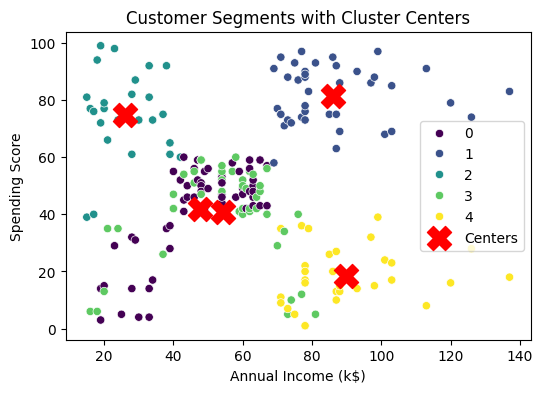

In [95]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.scatter(
    centers_original[:,1],
    centers_original[:,2],
    s=300,
    c='red',
    marker='X',
    label='Centers'
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

The final clustering results reveal five distinct customer segments based on income and spending behavior. The cluster centers, marked in red, represent the average characteristics of each group.

One segment consists of high-income, high-spending customers, representing premium and highly valuable customers. Another group includes high-income but low-spending customers, indicating an opportunity for targeted marketing to increase engagement. A third segment represents low-income but high-spending customers, suggesting strong purchasing behavior despite limited income. The remaining clusters consist of moderate-income and moderate-spending customers, forming the general customer base.

These insights enable businesses to design targeted marketing strategies, improve customer engagement, and allocate resources more effectively based on customer value.